# AIFUL monthly KPI forecasting — walkthrough

This notebook walks through the analysis behind the management report
(`reports/AIFUL_Monthly_Performance_Report_2026-08.pdf`). The heavy lifting lives in `src/`; the
notebook reads the outputs of `python run_all.py` so it runs in seconds.

**Question:** can public Japanese macro data improve forecasts of AIFUL's monthly business KPIs
beyond a plain time-series baseline?

In [1]:
import sys, json
sys.path.insert(0, '../src')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
import forecasting as F
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 20)
k, m = F.load()
print(k.shape, k.index.min(), '->', k.index.max())
k.tail()

(161, 18) 2013-04 -> 2026-08


,accounts_total_k,applications,contract_rate_pct,delinquency_ratio_pct,guarantee_mil,installment_mil,loans_outstanding_mil,new_accounts,refund_cash_mil,refund_claims,secured_accounts_k,secured_loans_mil,smallbiz_accounts_k,smallbiz_loans_mil,total_receivables_mil,transferred_loans_mil,unsecured_accounts_k,unsecured_loans_mil
month,,,,,,,,,,,,,,,,,,
2026-04,1417.0,83281.0,28.3,0.574,379735.0,125.0,675212.0,23602.0,182.0,60.0,0.0,1023.0,14.0,17559.0,1055073.0,NaN,1402.0,656628.0
2026-05,1432.0,92607.0,27.8,0.759,387931.0,125.0,683053.0,25741.0,124.0,60.0,0.0,1007.0,14.0,17736.0,1071110.0,NaN,1417.0,664309.0
2026-06,1415.0,78052.0,29.4,0.528,397189.0,121.0,676108.0,22974.0,157.0,70.0,0.0,977.0,14.0,17550.0,1073418.0,NaN,1400.0,657580.0
2026-07,1417.0,73882.0,28.7,0.756,408564.0,120.0,676416.0,21180.0,118.0,70.0,0.0,954.0,14.0,17554.0,1085101.0,NaN,1403.0,657907.0
2026-08,1430.0,80478.0,28.2,0.654,420574.0,119.0,682512.0,22657.0,110.0,50.0,0.0,938.0,14.0,17591.0,1103205.0,NaN,1415.0,663982.0


## 1. Data quality: parsed PDFs vs AIFUL's own published YoY figures
Every level was parsed from the PDFs; the PDFs also print YoY %. If parsing is right, the YoY computed from my levels must match theirs.

In [2]:
yoy = pd.read_csv('../data/processed/aiful_monthly_yoy_reported.csv', index_col=0)
yoy.index = pd.PeriodIndex(yoy.index, freq='M')
calc = (k / k.shift(12) - 1) * 100
cols = ['total_receivables_mil','loans_outstanding_mil','unsecured_loans_mil','accounts_total_k','applications','new_accounts']
pd.DataFrame({c: (calc[c] - yoy[c]).abs().describe()[['count','max']] for c in cols}).T.round(3)

,count,max
total_receivables_mil,149.0,0.050
loans_outstanding_mil,149.0,0.050
unsecured_loans_mil,149.0,0.050
accounts_total_k,149.0,0.175
applications,149.0,0.049
new_accounts,149.0,0.050


In [3]:
# contract rate published = new accounts / applications ?
(k.new_accounts / k.applications * 100 - k.contract_rate_pct).abs().max().round(3)

np.float64(0.05)

## 2. The business in three pictures

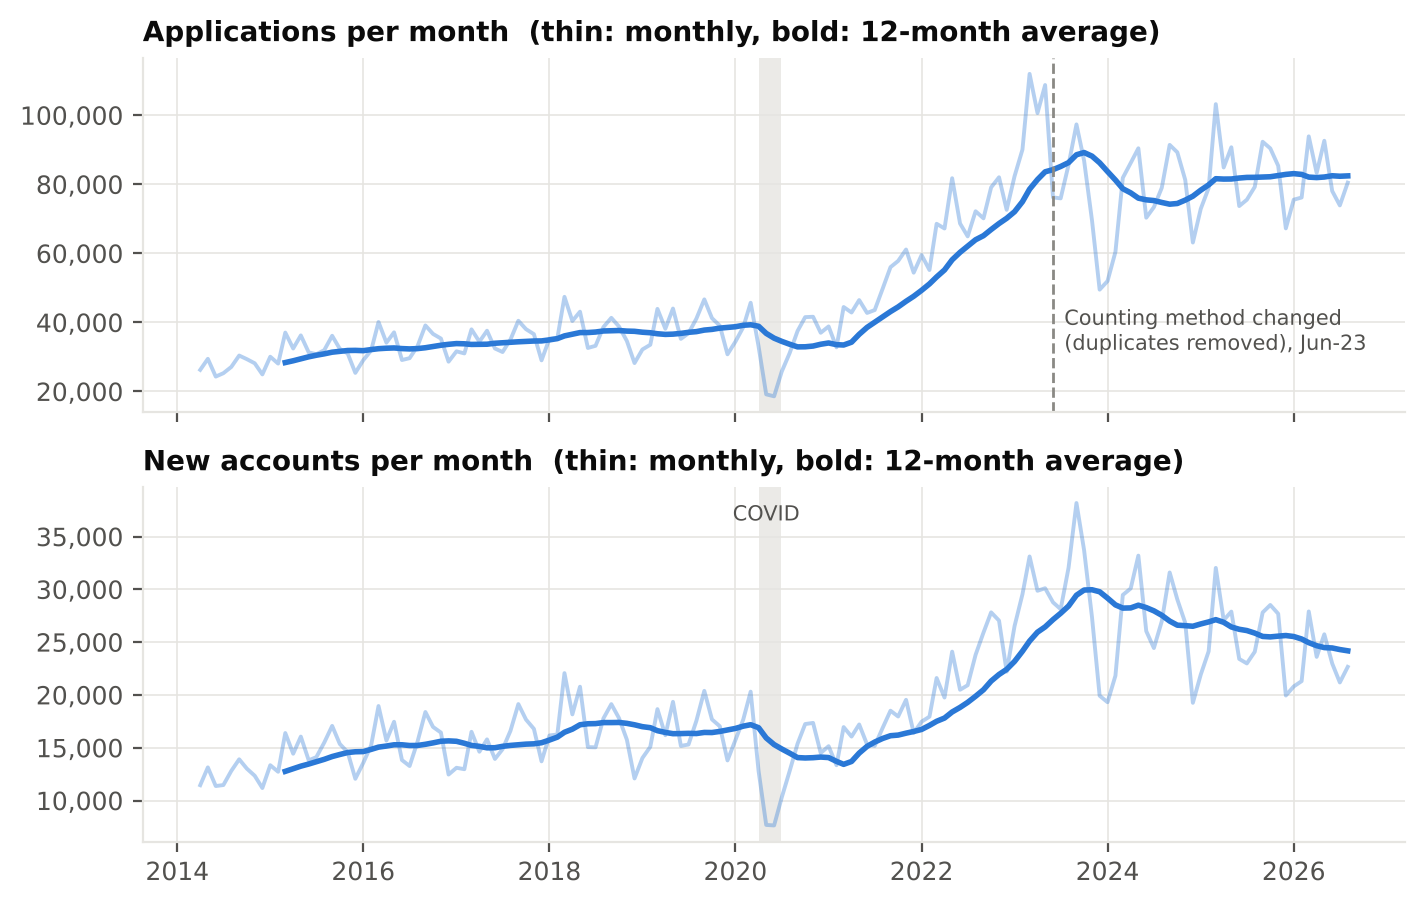

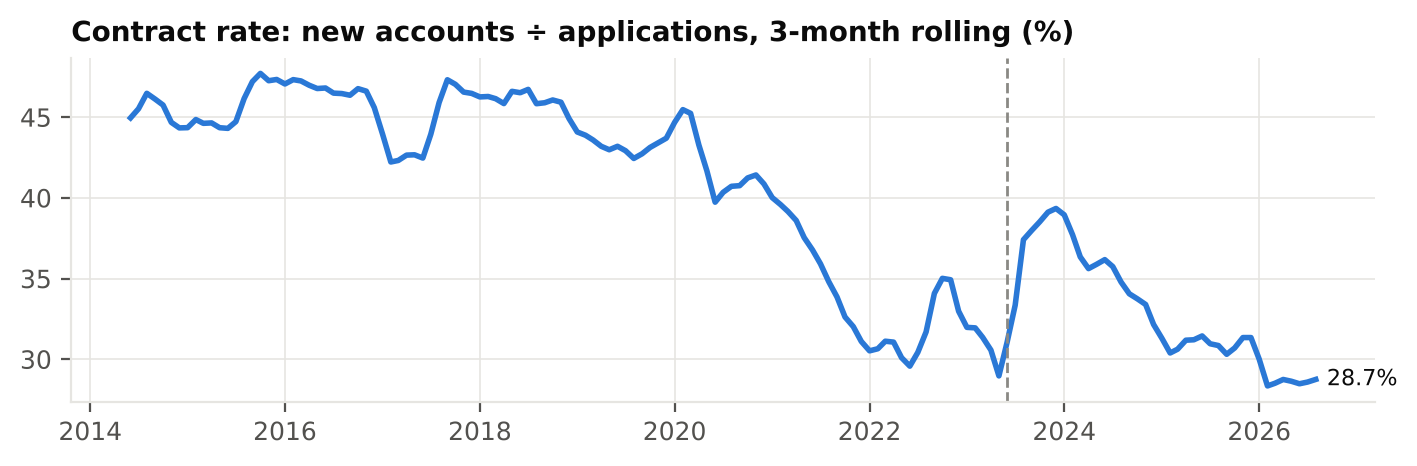

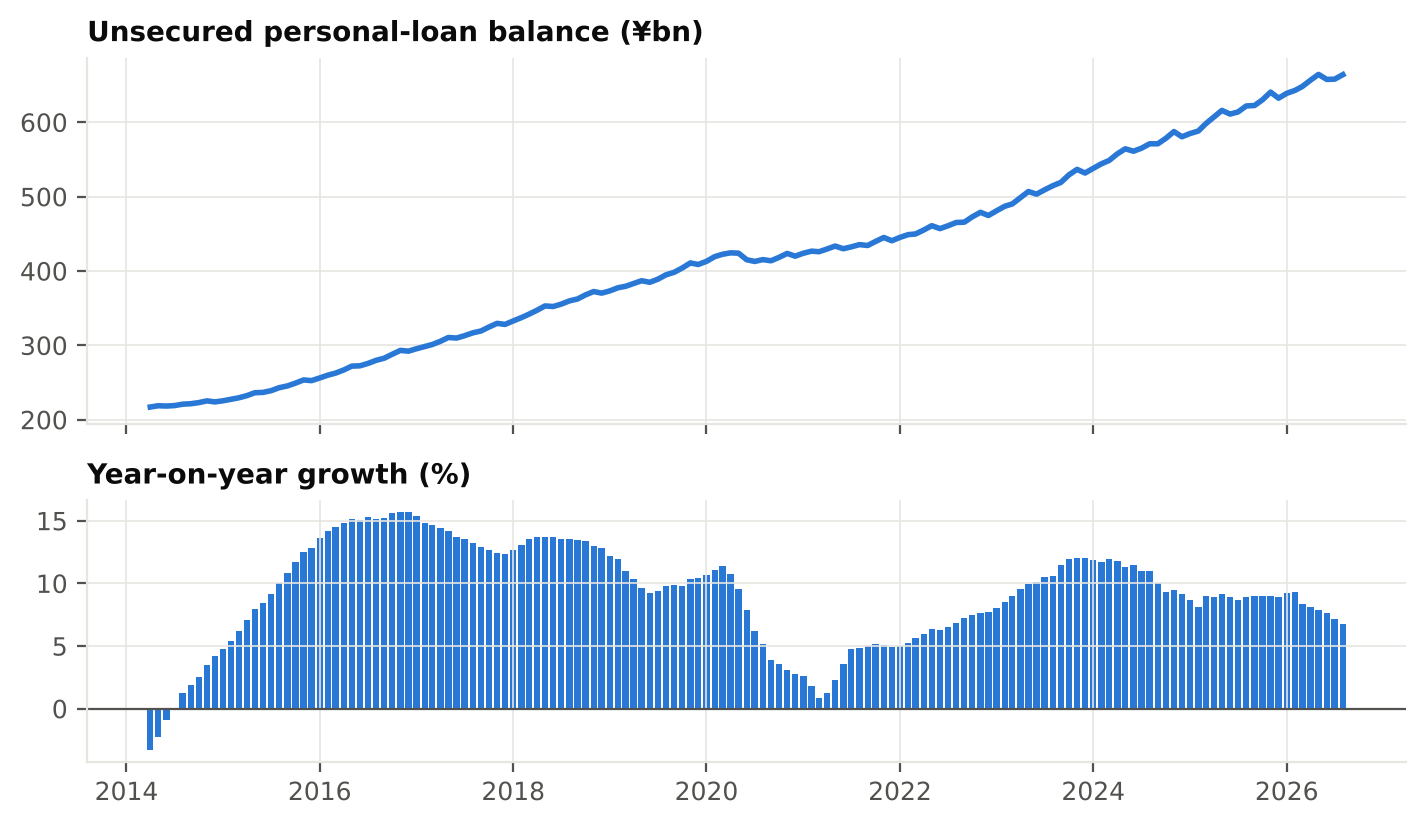

In [4]:
for f in ['01_funnel_volumes.png','02_contract_rate.png','03_balance.png']: display(Image('../reports/figures/'+f, width=750))

## 3. Is there a macro signal at all? (correlations of YoY growth with 6-month-lagged drivers)

In [5]:
y = np.log(k[F.TARGETS]).diff(12) * 100
mm = m.copy(); mm['d_unemp'] = m.unemployment_rate.diff(12)
drivers = ['d_unemp','consumer_confidence','core_cpi_yoy','real_wage_growth','call_rate']
corr = pd.DataFrame({d: y.loc['2015':].corrwith(mm[d].shift(6)) for d in drivers}).round(2)
corr

,d_unemp,consumer_confidence,core_cpi_yoy,real_wage_growth,call_rate
applications,0.15,-0.21,-0.14,0.01,-0.08
new_accounts,0.04,-0.17,-0.00,-0.11,-0.16
unsecured_loans_mil,-0.60,0.66,-0.01,0.25,-0.13


Applications and new accounts barely move with macro (|r| ≈ 0.2). Balance growth correlates strongly with unemployment and confidence, but both trends are dominated by the 2020-21 COVID slowdown, so this is weak evidence. The backtest is the real test.

## 4. Rolling-origin backtest (54 origins, h = 1..6)

,ets,lgbm,sarima,sarimax,snaive
target,,,,,
applications,11.13,15.03,11.08,11.35,19.88
new_accounts,11.27,14.43,10.98,10.89,17.82
unsecured_loans_mil,0.74,0.93,0.67,0.67,8.24


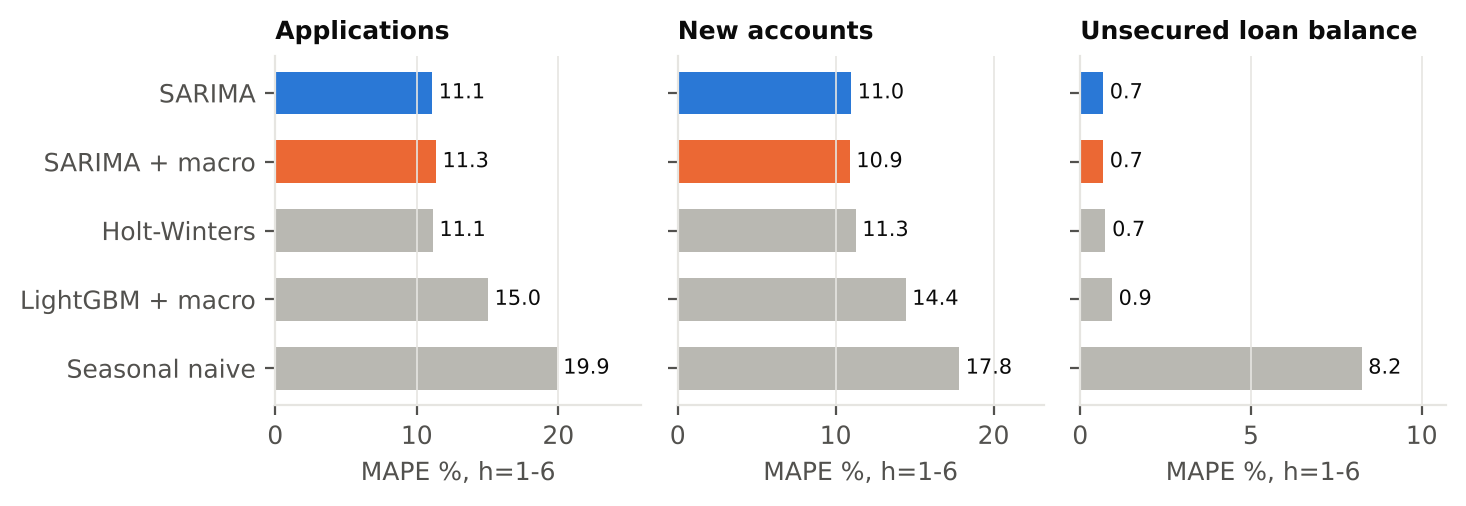

In [6]:
mape = pd.read_csv('../reports/tables/mape_by_model.csv', index_col=0)
display(mape)
display(Image('../reports/figures/05_backtest_mape.png', width=750))

In [7]:
pd.read_csv('../reports/tables/mape_by_horizon.csv', index_col=[0,1])

1      2      3      4      5      6
target              model                                            
applications        ets       6.23   9.86  11.61  12.73  12.79  13.57
                    lgbm      8.91  13.45  17.06  18.32  16.13  16.33
                    sarima    6.61   9.55  11.47  12.55  12.49  13.81
                    sarimax   7.38  10.16  11.91  12.51  12.73  13.42
                    snaive   21.22  20.73  20.18  19.69  19.09  18.36
new_accounts        ets       6.37   9.57  11.59  12.78  13.33  13.96
                    lgbm      8.07  13.27  14.40  16.81  17.36  16.67
                    sarima    6.52   9.40  11.27  12.29  12.77  13.67
                    sarimax   7.14   9.84  11.36  12.31  12.21  12.52
                    snaive   17.87  18.07  18.02  17.84  17.75  17.39
unsecured_loans_mil ets       0.32   0.49   0.64   0.84   0.97   1.16
                    lgbm      0.31   0.55   0.79   1.06   1.31   1.59
                    sarima    0.27   0.44   0.59   0.73   0.89   1.08
                    sarimax   0.29   0.46   0.62   0.73   0.88   1.07
                    snaive    8.13   8.18   8.22   8.27   8.30   8.33

### Does macro help? Diebold-Mariano test, SARIMAX vs SARIMA (negative statistic = macro better)

In [8]:
pd.read_csv('../reports/tables/macro_value_dm_test.csv')

,target,h,sarima_mae_log_pct,sarimax_mae_log_pct,dm_stat,p_value
0,applications,1,6.566,7.334,2.436,0.018
1,applications,2,9.418,10.052,1.148,0.256
2,applications,3,11.164,11.634,0.701,0.486
3,applications,4,12.113,12.107,0.268,0.790
4,applications,5,11.916,12.287,-0.247,0.806
5,applications,6,13.077,12.907,-0.471,0.639
6,new_accounts,1,6.494,7.129,1.537,0.130
7,new_accounts,2,9.306,9.784,0.768,0.446
8,new_accounts,3,10.976,11.158,0.398,0.692
9,new_accounts,4,11.896,12.064,-0.185,0.854


In [9]:
pd.read_csv('../reports/tables/macro_robustness_mape.csv', index_col=0)

,applications,new_accounts,unsecured_loans_mil
sarima (no macro),11.08,10.98,0.67
"baseline_set (d_unemp, CCI, core CPI)",11.35,10.89,0.67
consumer_confidence only,10.84,10.57,0.68
unemployment change only,11.72,11.59,0.66
CCI income + employment sub-indices,10.85,10.77,0.66
call rate + core CPI,13.44,13.12,0.68


**Conclusion:** no macro set improves accuracy materially. Consumer confidence alone is best by ~0.2-0.4pt,
but it was picked after seeing results, so the gain shouldn't count. Production model = SARIMA; macro is used for stress scenarios only.

## 5. In-sample: are the macro coefficients meaningful?

In [10]:
y_ = k['new_accounts']
ex = F.interventions(y_.index, 'new_accounts').join(F.macro_exog(m, y_.index))
fc_idx = pd.period_range(y_.index.max()+1, periods=1, freq='M')
res, _ = F._sarimax(y_, 1, ex, F.interventions(fc_idx,'new_accounts').join(F.macro_exog(m, fc_idx)), return_ci=True)
pd.DataFrame({'coef': res.params[:ex.shape[1]], 'p': res.pvalues[:ex.shape[1]]}, index=ex.columns).round(4)

,coef,p
covid,-0.4170,0.0000
d_unemp,0.1034,0.0423
consumer_confidence,-0.0114,0.0300
core_cpi_yoy,0.0361,0.1121


Counter-cyclical and significant in-sample (weaker confidence / rising unemployment → more new accounts 6 months later), but too small relative to company-driven swings to help out of sample.

## 6. Forecast and scorecard

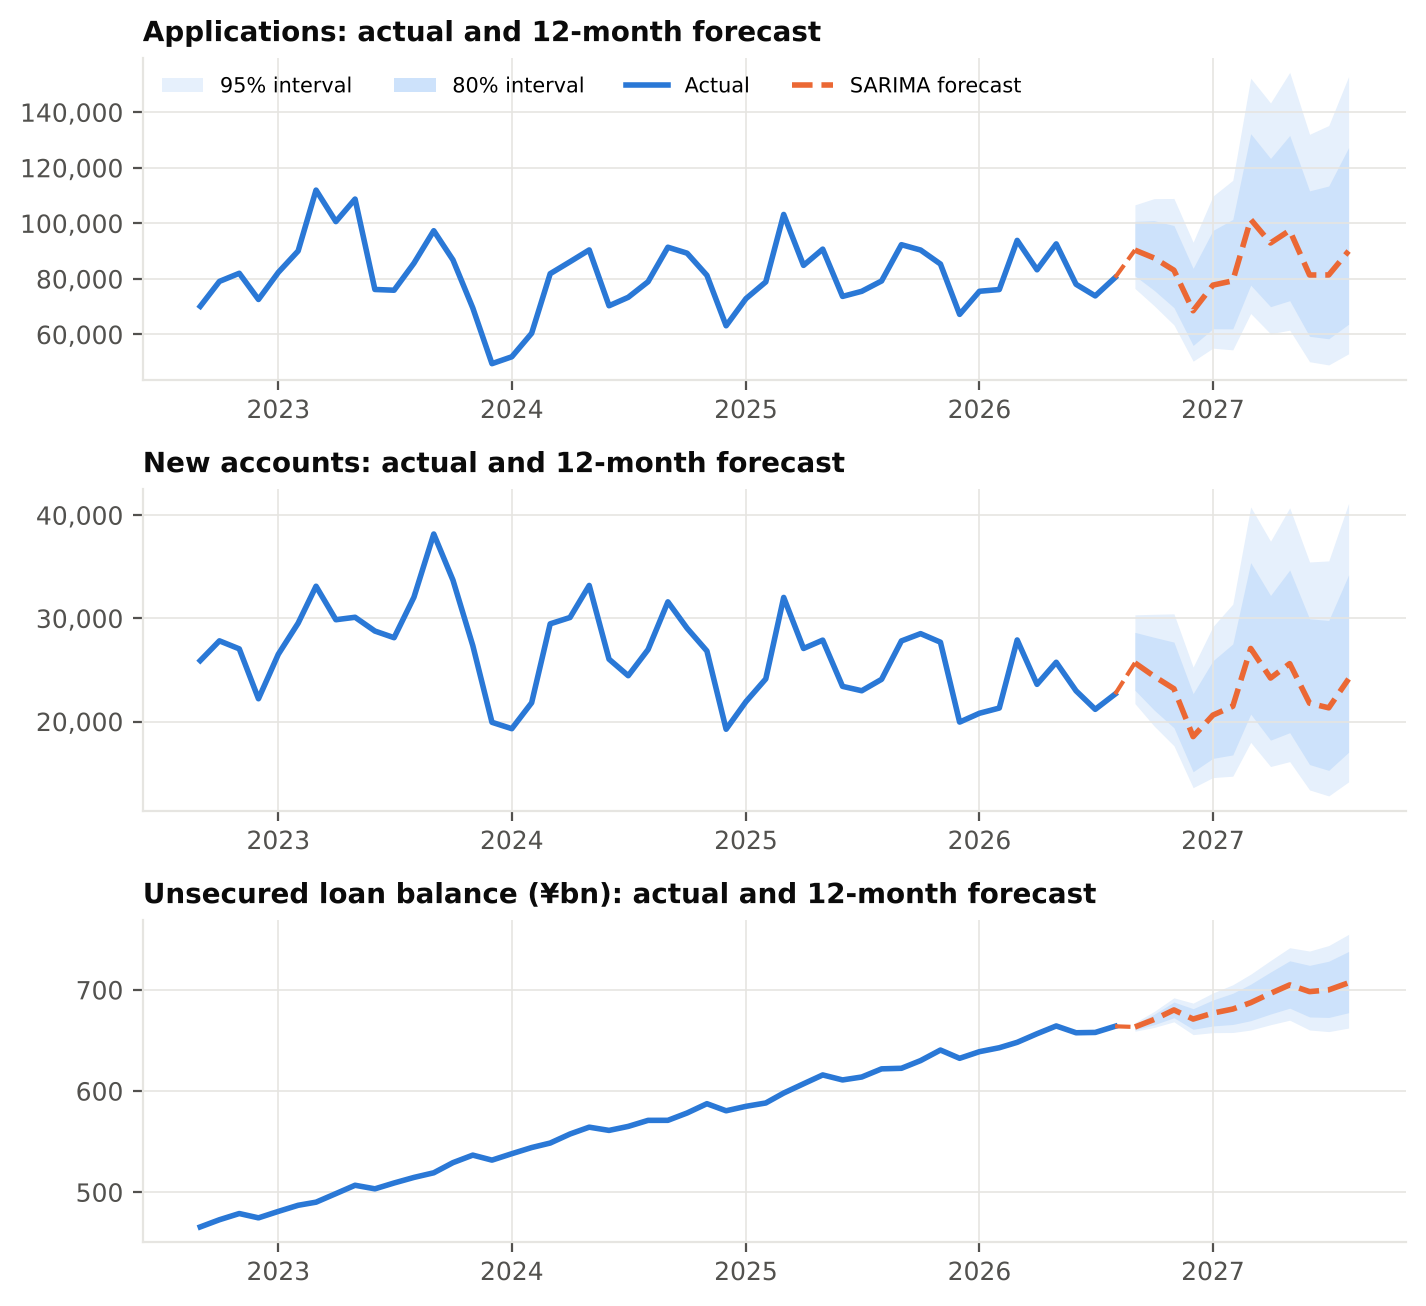

,target,month,mean,lo80,hi80,lo95,hi95
0,applications,2026-09,90370.0,81088.0,100713.0,76568.0,106660.0
1,applications,2026-10,87534.0,75889.0,100966.0,70366.0,108892.0
2,applications,2026-11,83132.0,69657.0,99213.0,63432.0,108950.0
3,applications,2026-12,68526.0,56039.0,83796.0,50378.0,93212.0
4,applications,2027-01,77764.0,62056.0,97447.0,55070.0,109810.0
5,applications,2027-02,79302.0,62020.0,101399.0,54453.0,115490.0
6,applications,2027-03,101414.0,77748.0,132283.0,67545.0,152264.0
7,applications,2027-04,92929.0,69998.0,123372.0,60247.0,143340.0
8,applications,2027-05,97462.0,72160.0,131637.0,61545.0,154341.0
9,applications,2027-06,81407.0,59332.0,111693.0,50185.0,132052.0


In [11]:
display(Image('../reports/figures/06_forecasts.png', width=750))
pd.read_csv('../reports/tables/forecast_12m_sarima.csv').round(0).head(12)

In [12]:
pd.read_csv('../reports/tables/scorecard_latest_month.csv').round(2)

,kpi,unit,actual,last_year,yoy_pct,yoy_pt,forecast_1m,vs_forecast_pct,fytd,fytd_ly,fytd_yoy_pct
0,applications,count,80478.00,79253.00,1.55,NaN,82227.30,-2.13,408300.0,404061.0,1.05
1,new_accounts,count,22657.00,24088.00,-5.94,NaN,24294.35,-6.74,116154.0,125444.0,-7.41
2,contract_rate_pct,%,28.20,30.40,NaN,-2.20,NaN,NaN,NaN,NaN,NaN
3,unsecured_loans_mil,¥mil,663982.00,621893.00,6.77,NaN,663362.37,0.09,NaN,NaN,NaN
4,accounts_total_k,'000,1430.00,1379.00,3.70,NaN,NaN,NaN,NaN,NaN,NaN
5,delinquency_ratio_pct,%,0.65,0.75,NaN,-0.09,NaN,NaN,NaN,NaN,NaN
6,refund_claims,count,50.00,120.00,-58.33,NaN,NaN,NaN,310.0,630.0,-50.79


In [13]:
pd.read_csv('../reports/tables/macro_scenarios.csv')

,target,scenario,value_12m,vs_base_pct
0,applications,base (macro held flat),1051241.42,0.00
1,applications,"downside: unemp +0.7pp, CCI -6, core CPI +1pp",1131852.51,7.67
2,applications,"upside: unemp -0.3pp, CCI +3",1025217.06,-2.48
3,new_accounts,base (macro held flat),286350.54,0.00
4,new_accounts,"downside: unemp +0.7pp, CCI -6, core CPI +1pp",319088.10,11.43
5,new_accounts,"upside: unemp -0.3pp, CCI +3",275665.57,-3.73
6,unsecured_loans_mil,base (macro held flat),705635.76,0.00
7,unsecured_loans_mil,"downside: unemp +0.7pp, CCI -6, core CPI +1pp",706798.07,0.16
8,unsecured_loans_mil,"upside: unemp -0.3pp, CCI +3",705142.01,-0.07
